In [2]:
import numpy as np
import scipy
import matplotlib.pyplot as plt

Problem-1) Design of a Can (60 points)

The purpose of this project is to design a can, shown in Figure, to hold at least 400 mL of
liquid (1 mL = 1 cm3), as well as to meet other design requirements. The cans will be
produced in the billions, so it is desirable to minimize their manufacturing costs. The cost
can be directly related to the surface area of the sheet metal used.
Fabrication, handling, aesthetics, and shipping considerations impose the following
restrictions on the size of the can: The diameter should be no more than 8 cm and no less
than 3.5 cm, whereas the height should be no more than 18 cm and no less than 8 cm.
Solve the design problem with a gradient-based optimization algorithm. Report the
optimum values of the objective function and design variables. Verify your optimum
solution (You can use a Matlab built-in function to verify your solution).

In [3]:
# Steepest Decent + Alternate Interval Search + Composite Objective Function

Volume_Min = 400 
Diameter_Bounds = np.array([3.5, 8])
Height_Bounds = np.array([8, 18])

Volume = lambda x : (np.pi/4) * x[1] * x[0] ** 2
Volume_Constraint = lambda x : Volume_Min - Volume(x)
Surface_Area = lambda x : 2 * (np.pi/4) * x[0] ** 2 + np.pi * x[0] * x[1]
Gradient_SA = lambda x: np.array([4 * (np.pi/4) * x[0] + np.pi * x[1], np.pi * x[0]])
Initial_Guess = np.array([9,9])

# g(x) =< 0: 
# 400 - (np.pi/4) * x[1] * x[0] ** 2 <= 0
# 3.5 - x[0] <= 0 
# x[0] - 8 <= 0 
# 8 - x[1] <= 0 
# x[1] - 18 <= 0 


x_k = Initial_Guess
r1 = 0.1
r2 = 0.06
r3 = 0.006
r4 = 0.006
r5 = 0.006
P = lambda x: (r1 * (400 - (np.pi/4) * x[1] * x[0] ** 2) ** 2
               + r2 * max(0,3.5 - x[0]) ** 2 
               + r3 * max(0,x[0] - 8) ** 2 
               + r4 * max(0,8 - x[1]) ** 2 
               + r5 * max(0,x[1] - 18) ** 2)

Phi = lambda x: Surface_Area(x) + P(x)
Gradient_P = lambda x: np.array([
    r1 * 2 * ( 400 - (np.pi/4) * x[1] * x[0] ** 2) * (-2 * (np.pi/4) * x[1] * x[0]) 
    + r2 * max(0,- 2 * (3.5 - x[0]))
    + r3 * max(0,2 * (x[0] - 8)),
    r1 * 2 * (400 - (np.pi/4) * x[1] * x[0] ** 2) * (-(np.pi/4) * x[0] ** 2)
    + r4 * max(0, - (8 - x[1]))
    + r5 * max(0, 2 * (x[1] - 18))])
Gradient_Phi = lambda x: Gradient_P(x) + Gradient_SA(x)
k = 0
error = 10e-6
c = 0

# Gradient Check 
h = 0.00001
h0 = np.array([h,0])
h1 = np.array([0,h])
Grad_test = np.array([(Phi(Initial_Guess+h0) - Phi(Initial_Guess-h0)) / (2*h), (Phi(Initial_Guess+h1) - Phi(Initial_Guess-h1)) / (2*h)])
print(Grad_test, Gradient_Phi(Initial_Guess))
while k < 100000:
    c = -Gradient_Phi(x_k)
    if np.linalg.norm(c) < error:
        break
        
    # Alpha
    Final_Interval_Length = 0.000001
    d = 0.0001
    q = 1
    Step_count = 0
    
    while True:
        if Phi(x_k + c * (q - 1) * d) <= Phi(x_k + c * d * q):
            break
        q = q + 1
    a_e = (q) * d 
    a_u = (q + 1) * d
    Interval_Length = a_u - a_e
    
    while Interval_Length > Final_Interval_Length:
        Interval_Length = a_u - a_e
        a_a = a_e + Interval_Length *(1/3)
        a_b = a_e + Interval_Length *(2/3)
        fa_e = Phi(x_k + a_e * c)
        fa_a = Phi(x_k + a_a * c)
        fa_b = Phi(x_k + a_b * c)
        fa_u = Phi(x_k + a_u * c)
        if fa_a < fa_b:
            a_u = a_b
        else:
            a_e = a_a
        
    alpha = (a_e + a_u)/2
    x_k = x_k + alpha * c
    k += 1
print("Error:", np.linalg.norm(c))
print("Steps:", k)
print("Diameter: " + str(x_k[0]) + "cm")
print("Height: " + str(x_k[1]) + "cm")
print("Volume: " + str(Volume(x_k)) + "cm^3")
print("Surface Area: " + str(Surface_Area(x_k)) + "cm^2")




[4447.55722708 2223.77261343] [4448.21722713 2223.77861357]
Error: 9.998674065020314e-06
Steps: 39968
Diameter: 7.913344419937087cm
Height: 8.081596219793454cm
Volume: 397.4725729067811cm^3
Surface Area: 299.27742881777004cm^2


Diameter: 7.978845608028666cm
Height: 8.0cm
Volume: 400.00000000000125cm^3
Surface Area: 300.53026197048064cm^2


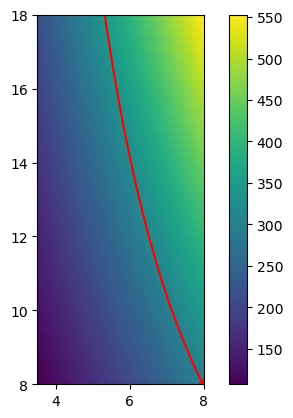

In [4]:
# Verification 
Results = scipy.optimize.minimize(
    Surface_Area, 
    Initial_Guess, 
    bounds = np.array([Diameter_Bounds, Height_Bounds]),  
    method = 'SLSQP',
    constraints = (scipy.optimize.NonlinearConstraint(Volume_Constraint, 0, 0)))

print("Diameter: " + str(Results.x[0]) + "cm")
print("Height: " + str(Results.x[1]) + "cm")
print("Volume: " + str(Volume(Results.x)) + "cm^3")
print("Surface Area: " + str(Surface_Area(Results.x)) + "cm^2")

diameter = np.linspace(Diameter_Bounds[0],Diameter_Bounds[1],50)
height = np.linspace(Height_Bounds[0],Height_Bounds[1],50)
dd, hh = np.meshgrid(diameter, height)
Surface_Area_Plot = Surface_Area([dd, hh])
Volume_Plot = Volume([dd, hh])
im = plt.imshow(np.flip(Surface_Area_Plot, axis = 0), extent=[Diameter_Bounds[0],Diameter_Bounds[1],Height_Bounds[0],Height_Bounds[1]])
plt.contour(Volume_Plot, levels = np.array([400]), colors = 'r', extent=[Diameter_Bounds[0],Diameter_Bounds[1],Height_Bounds[0],Height_Bounds[1]])
plt.scatter(Results.x[0], Results.x[1], edgecolors = 'r')
plt.colorbar(im)

Problem-2) Air Pollution Control Model (40 points)
Electric power generating plants have been criticized for contributing excessively to air
pollution problems. The emissions from plant smokestacks contain pollutants of various
kinds that are considered harmful to the environment. As a result, power plants are
subject to regulations governing the amounts of specific pollutants that are allowed in
the stack emissions.
A steam power plant has a choice of burning coal, oil and natural gas at the same time
and in any combination to generate power. The fuels must provide heat input to the plant
of 40×108 BTU/hr to generate the required power out.
Air pollution criteria must be met, and so the choice of fuel is not based only on the cost
and efficiency. The following table gives the necessary data for cost in per ton, heating
value in BTU per pound (lb) and pollutants produced in lb per ton for each of the fuels.
The maximum allowable limit for each of the pollutants in lb/hr is also given in the table.
Note that standard ton is used; i.e., 1 ton = 2000 lb.
An electrostatic precipitator can also be installed to remove particulate matter for $5 per
pound of particulate removed. This could be a cost-effective way to remove particulate
matter, and therefore needs to be considered in the formulation of the problem.
Formulate the problem and determine the fuel usage policy on per hour basis that
minimizes the cost of fuels and meets the air pollution requirements. Report the
optimum values of the objective function and design variables. Verify your optimum
solution (You can use a Matlab built-in function to verify your solution).
Reminders for Some Matlab Functions
- linprog: Solves LP problems
- quadprog: Solves QP problems (such as the QP sub-problem of SQP algorithm)
- fmincon: Constrained optimization solver using gradient-based algorithms (works for
unconstrained problems as well)


In [1]:
Heat_Required = 40 * 10 ** 8

# Coefficients matrix
A = np.array([
    [1.0, 2, 1, 0],  # Hydrocarbons
    [1, 1, 1, 0],     # NOx
    [140, 80, 1, 0],   # SOx
    [100, 90, 90, 0],  # CO
    [6, 2, 1, -1],     # Particulate
    [-14000 * 2000, -19000 * 2000, -22000 * 2000, 0],
    [-1, 0, 0, 0],
    [0, -1, 0, 0],
    [0, 0, -1, 0],
    [0, 0, 0, -1]# Heating Value
])

# Right-hand side (constraints)
b = np.array([100, 100, 2000, 20000, 80, -Heat_Required,0,0,0,0])

# Objective function coefficients (cost vector)
c = np.array([60, 100, 160, 5])

# If someone is reading that, I tried simplex but it required artificial variables and I gave up on that since I believe we never covered that. I tried though. The book also does this method so I believe it's valid. I will use the brute force method.

# There are 4 design variables so 4 active constraints.

opts = [] # This lists all the combinations of 4 rows.  
for i in range(0, 10):
    for j in range(i+1, 10):
        for k in range(j+1, 10):
            for n in range(k+1, 10):
                opts.append([i,j,k,n])

print(opts)

# Assumes the set of constraints is active and tests them. 
X = np.zeros([len(opts),4])
Costs = np.zeros([len(opts)])
for i, opt in enumerate(opts):
    A_sub = np.array([A[opt[0]],A[opt[1]],A[opt[2]],A[opt[3]]])
    B_sub = np.array([b[opt[0]],b[opt[1]],b[opt[2]],b[opt[3]]])
    # Just normal linear algebra. If it is a singular matrix it just gives up. It's singular when X3 is unused. 
    try: 
        X[i] = np.linalg.solve(A_sub,B_sub)
    except:
        X[i] = np.array([np.inf, np.inf, np.inf, np.inf])
    
    Costs[i] = np.dot(c,X[i])


def Valididty_Check(x):
    if x[0] == np.inf:
        return False
    sol = A @ x

    for i, const in enumerate(sol):
        if const > b[i]+0.0001: # Rounding error buffer
            return False
    
    return True
    
        

Validity = np.zeros([len(opts)])
for i in range(len(opts)):
    Validity[i] = Valididty_Check(X[i])

min_i = 0
min_cost = np.inf
print("\nAll Valid Solution Candidates:")
for i, val in enumerate(Validity):
    if val: 
        if Costs[i] < min_cost:
            min_cost = Costs[i]
            min_i = i 
        print("Coal (ton/hr): ", X[i,0])
        print("Oil: (ton/hr)", X[i,1])
        print("Gas: (ton/hr)", X[i,2])
        print("Removal (ton/hr): ", X[i,2])
        print("Cost: ", Costs[i])
        print("\n")

print("\nMinimum Solution:")
print("Coal (ton/hr): ", X[min_i,0])
print("Oil: (ton/hr)", X[min_i,1])
print("Gas: (ton/hr)", X[min_i,2])
print("Removal (ton/hr): ", X[min_i,2])
print("Cost: ", Costs[min_i])
print("\n")

NameError: name 'np' is not defined

In [24]:
Heat_Required = 40 * 10 ** 8

Hydrocarbons = np.array([1, 2, 1, 0])
NOx = np.array([1, 1, 1, 0])
SOx = np.array([140, 80, 1, 0])
CO = np.array([100, 90, 90, 0])
Particulate = np.array([6, 2, 1, -1])
Cost = np.array([60, 100, 160, 5])
Cost_func = lambda x: np.dot(x, Cost)
Heating_Value = np.array([14000, 19000, 22000, 0]) * 2000

# Verification
Pollution_Constraints = (
    scipy.optimize.LinearConstraint(Hydrocarbons, lb=0, ub=100),
    scipy.optimize.LinearConstraint(NOx, lb=0, ub=100),
    scipy.optimize.LinearConstraint(SOx, lb=0, ub=2000),
    scipy.optimize.LinearConstraint(CO , lb=0, ub=20000),
    scipy.optimize.LinearConstraint(Particulate, lb=0, ub=80),
    scipy.optimize.LinearConstraint(Heating_Value, lb=Heat_Required, ub=np.inf)
)

Initial_Guess = np.array([140, 150, 150, 8])

Results = scipy.optimize.minimize(
    Cost_func,
    Initial_Guess,
    constraints = Pollution_Constraints,
    bounds = ((0, np.inf), (0, np.inf), (0, np.inf), (0, np.inf))
)

Res_x = Results.x
print("Coal: " + str(Res_x[0]) + " ton/hr")
print("Oil: " + str(Res_x[1]) + " ton/hr")
print("Gas: " + str(Res_x[2]) + " ton/hr")
print("Removal: " + str(Res_x[3]) + " lb/hr")
print("Hydrocarbons: " + str(np.dot(Hydrocarbons, Res_x)) + " lb/hr")
print("NOx: " + str(np.dot(NOx, Res_x)) + " lb/hr")
print("SOx: " + str(np.dot(SOx, Res_x)) + " lb/hr")
print("CO: " + str(np.dot(CO, Res_x)) + " lb/hr")
print("Particulate: " + str(np.dot(Particulate, Res_x)) + " lb/hr")
print("Cost: " + str(Cost_func(Res_x)) + " $/hr")
print("Heat Val:" + str(np.dot(Heating_Value, Res_x)) + "BTU/hr")
print("Heat Val? " + str(np.dot(Heating_Value, Res_x) - Heat_Required))

Coal: 11.189056472283706 ton/hr
Oil: 4.419501930572854 ton/hr
Gas: 79.97193967258538 ton/hr
Removal: 75.94528235715761 lb/hr
Hydrocarbons: 100.0000000060148 lb/hr
NOx: 95.58049807544194 lb/hr
SOx: 2000.0000002381325 lb/hr
CO: 8714.135391512611 lb/hr
Particulate: 80.00000001027571 lb/hr
Cost: 14288.530340793757 $/hr
Heat Val:4000000000.179469BTU/hr
Heat Val? 0.17946910858154297


In [16]:
max(0,-2)

0